# Election Bloc Change Prediction Project
## Notebook 03 — EDA and transparent temporal baselines

**Final corrected version based on the full Notebook 02 output: K16–K25, nine transitions.**

### Trusted Notebook 02 inputs

- `data/interim/election_transition_panel.csv`
- `reports/tables/transition_panel_quality_checks.csv`
- `reports/tables/election_transition_match_audit.csv`
- `reports/tables/notebook_02_input_election_audit.csv`
- `reports/summaries/notebook_02_summary.json`

### Evaluation policy

- The first eight transitions, `K16_to_K17` through `K23_to_K24`, are development data.
- `K24_to_K25` is the locked final test.
- The locked transition is validated structurally but is not used for EDA, baseline fitting, baseline comparison, model selection, or reported performance.
- Primary evaluation is rolling temporal validation with at least three earlier transitions in every training fold.

### Why the baselines are transparent

The notebook compares persistence with simple drift baselines that use only earlier transitions:

1. **Persistence** — the next composition equals the previous composition.
2. **Expanding mean CLR shift** — add the mean historical CLR change observed before the test transition.
3. **Expanding median CLR shift** — add the median historical CLR change.
4. **Last-transition mean CLR shift** — use the mean CLR shift from the immediately preceding transition.
5. **Locality historical mean CLR shift** — use each locality's own earlier mean CLR change, with a training-only global fallback.

All CLR predictions are transformed back to valid four-bloc compositions that sum to 100%.

### Important Notebook 02 findings addressed here

- All ten elections and all nine transitions are present.
- Matching coverage is above 99% of votes in every transition.
- Knesset 17 does not contain eligible-voter or turnout data; this notebook does not use turnout as a baseline feature.
- `K16_to_K17` is a major structural-break transition, so all performance is shown fold by fold rather than hidden inside one pooled score.

## 0. Fresh repository checkout and environment

In [1]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import json
import shutil
import subprocess
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 360)
pd.set_option('display.max_rows', 200)

REPO_URL = 'https://github.com/IfatDav/Election_Bloc_Prediction_Project.git'
REPO_ROOT = Path('/content/Election_Bloc_Prediction_Project_nb03')

# Always use a fresh checkout so Notebook 03 cannot read stale local outputs.
if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

subprocess.run(
    [
        'git',
        'clone',
        '--depth',
        '1',
        REPO_URL,
        str(REPO_ROOT),
    ],
    check=True,
)

GIT_COMMIT = subprocess.check_output(
    [
        'git',
        '-C',
        str(REPO_ROOT),
        'rev-parse',
        'HEAD',
    ],
    text=True,
).strip()

INTERIM_DIR = REPO_ROOT / 'data' / 'interim'
TABLES_DIR = REPO_ROOT / 'reports' / 'tables'
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
SUMMARIES_DIR = REPO_ROOT / 'reports' / 'summaries'

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MODELED_BLOCS = [
    'Right',
    'Center_Left',
    'Haredi',
    'Arab',
]

EXPECTED_TRANSITIONS = [
    f'K{number}_to_K{number + 1}'
    for number in range(16, 25)
]

DEVELOPMENT_TRANSITIONS = EXPECTED_TRANSITIONS[:-1]
FINAL_TEST_TRANSITION = EXPECTED_TRANSITIONS[-1]
MINIMUM_TRAIN_TRANSITIONS = 3
ARAB_MAJORITY_THRESHOLD_PCT = 50.0
BASELINE_NAMES = [
    'Persistence',
    'Expanding mean CLR shift',
    'Expanding median CLR shift',
    'Last-transition mean CLR shift',
    'Locality historical mean CLR shift',
]

PANEL_PATH = INTERIM_DIR / 'election_transition_panel.csv'
NB02_QUALITY_PATH = TABLES_DIR / 'transition_panel_quality_checks.csv'
MATCH_AUDIT_PATH = TABLES_DIR / 'election_transition_match_audit.csv'
INPUT_AUDIT_PATH = TABLES_DIR / 'notebook_02_input_election_audit.csv'
NB02_SUMMARY_PATH = SUMMARIES_DIR / 'notebook_02_summary.json'

required_input_paths = [
    PANEL_PATH,
    NB02_QUALITY_PATH,
    MATCH_AUDIT_PATH,
    INPUT_AUDIT_PATH,
    NB02_SUMMARY_PATH,
]

missing_inputs = [
    str(path.relative_to(REPO_ROOT))
    for path in required_input_paths
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        'Required Notebook 02 files are missing from GitHub:\n- '
        + '\n- '.join(missing_inputs)
    )

print('Fresh repository:', REPO_ROOT)
print('Git commit:', GIT_COMMIT)
print('Transition panel:', PANEL_PATH)

Fresh repository: /content/Election_Bloc_Prediction_Project_nb03
Git commit: 21d425366e314e50c6d86bcb0e4a09ea10eadc0f
Transition panel: /content/Election_Bloc_Prediction_Project_nb03/data/interim/election_transition_panel.csv


## 1. Validate Notebook 02 audits before reading the modeling panel

In [2]:
nb02_quality = pd.read_csv(
    NB02_QUALITY_PATH,
    encoding='utf-8-sig',
)

if not {'check', 'passed', 'value', 'requirement'}.issubset(
    nb02_quality.columns
):
    raise KeyError(
        'Notebook 02 quality-check file has an unexpected schema.'
    )

nb02_quality['passed'] = (
    nb02_quality['passed']
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(['true', '1', 'yes'])
)

failed_nb02_checks = nb02_quality.loc[
    ~nb02_quality['passed']
]

if not failed_nb02_checks.empty:
    raise RuntimeError(
        'Notebook 02 contains failed quality checks:\n'
        + failed_nb02_checks.to_string(index=False)
    )

match_audit = pd.read_csv(
    MATCH_AUDIT_PATH,
    encoding='utf-8-sig',
)

input_election_audit = pd.read_csv(
    INPUT_AUDIT_PATH,
    encoding='utf-8-sig',
)

with NB02_SUMMARY_PATH.open('r', encoding='utf-8') as file:
    nb02_summary = json.load(file)

if nb02_summary.get('version') != 'full_history_K16_K25':
    raise ValueError(
        'Notebook 02 summary is not the full-history K16–K25 version.'
    )

if nb02_summary.get('transitions') != EXPECTED_TRANSITIONS:
    raise ValueError(
        'Notebook 02 summary does not contain the expected nine transitions.'
    )

if nb02_summary.get('final_test_transition') != FINAL_TEST_TRANSITION:
    raise ValueError(
        'Notebook 02 summary identifies the wrong final-test transition.'
    )

if not bool(nb02_summary.get('final_test_locked')):
    raise ValueError(
        'Notebook 02 summary does not mark the final test as locked.'
    )

minimum_previous_vote_coverage = float(
    pd.to_numeric(
        match_audit['matched_previous_vote_coverage_pct'],
        errors='coerce',
    ).min()
)

minimum_current_vote_coverage = float(
    pd.to_numeric(
        match_audit['matched_current_vote_coverage_pct'],
        errors='coerce',
    ).min()
)

if minimum_previous_vote_coverage < 95:
    raise ValueError('Previous-election vote matching coverage is below 95%.')

if minimum_current_vote_coverage < 95:
    raise ValueError('Current-election vote matching coverage is below 95%.')

k17_audit = input_election_audit.loc[
    pd.to_numeric(
        input_election_audit['election_number'],
        errors='coerce',
    ).eq(17)
]

if k17_audit.empty:
    raise ValueError('Knesset 17 is missing from the Notebook 02 input audit.')

print('Notebook 02 audits passed.')
print('Notebook 02 panel rows:', nb02_summary.get('panel_rows'))
print('Notebook 02 unique localities:', nb02_summary.get('unique_localities'))
print('Minimum previous vote coverage:', minimum_previous_vote_coverage)
print('Minimum current vote coverage:', minimum_current_vote_coverage)
print('K17 missing turnout rows:', int(k17_audit['missing_turnout_pct'].iloc[0]))

display(nb02_quality)
display(match_audit)

Notebook 02 audits passed.
Notebook 02 panel rows: 10658
Notebook 02 unique localities: 1226
Minimum previous vote coverage: 99.08298637462318
Minimum current vote coverage: 99.51108904900369
K17 missing turnout rows: 1148


,check,passed,value,requirement
0,all_ten_elections_available_in_input,True,"[16, 17, 18, 19, 20, 21, 22, 23, 24, 25]","[16, 17, 18, 19, 20, 21, 22, 23, 24, 25]"
1,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
2,no_duplicate_transition_locality_rows,True,0,0
3,minimum_matched_localities_per_transition,True,1139,>= 1000
4,minimum_previous_vote_coverage,True,99.08298637462318,>= 95.0%
5,minimum_current_vote_coverage,True,99.51108904900367,>= 95.0%
6,previous_compositions_sum_to_100,True,2.842170943040401e-14,<= 1e-6
7,current_compositions_sum_to_100,True,2.842170943040401e-14,<= 1e-6
8,percentage_point_deltas_sum_to_zero,True,4.707345624410664e-14,<= 1e-6
9,inverse_clr_reconstruction_is_precise,True,5.551115123125783e-16,<= 1e-10


,transition_id,previous_election_number,current_election_number,previous_rows,current_rows,matched_rows,previous_only_rows,current_only_rows,matched_previous_row_coverage_pct,matched_current_row_coverage_pct,matched_previous_vote_coverage_pct,matched_current_vote_coverage_pct
0,K16_to_K17,16,17,1171,1148,1139,32,9,97.267293,99.216028,99.082986,99.970260
1,K17_to_K18,17,18,1148,1156,1140,8,16,99.303136,98.615917,99.894628,99.909818
2,K18_to_K19,18,19,1156,1184,1155,1,29,99.913495,97.550676,99.999937,99.511089
3,K19_to_K20,19,20,1184,1195,1183,1,12,99.915541,98.995816,99.999190,99.958574
4,K20_to_K21,20,21,1195,1213,1193,2,20,99.832636,98.351195,99.995224,99.906570
5,K21_to_K22,21,22,1213,1213,1212,1,1,99.917560,99.917560,99.998600,99.996921
6,K22_to_K23,22,23,1213,1213,1213,0,0,100.000000,100.000000,100.000000,100.000000
7,K23_to_K24,23,24,1213,1214,1211,2,3,99.835120,99.752883,99.988340,99.993958
8,K24_to_K25,24,25,1214,1215,1212,2,3,99.835255,99.753086,99.898607,99.897864


## 2. Load and validate the full transition panel

In [3]:
def normalize_locality_symbol(series):
    normalized = series.astype('string').str.strip()
    normalized = normalized.str.replace(
        r'\.0+$',
        '',
        regex=True,
    )
    return normalized.replace(
        {'': pd.NA, 'nan': pd.NA, 'None': pd.NA}
    )


panel = pd.read_csv(
    PANEL_PATH,
    dtype={'locality_symbol': 'string'},
    low_memory=False,
)

panel['locality_symbol'] = normalize_locality_symbol(
    panel['locality_symbol']
)

required_columns = {
    'locality_symbol',
    'locality_name',
    'transition_id',
    'transition_order',
    'final_test_locked',
    'data_role',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'previous_valid_votes',
    'current_valid_votes',
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'previous_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
}

missing_columns = sorted(
    required_columns - set(panel.columns)
)

if missing_columns:
    raise KeyError(
        'Notebook 02 transition panel is missing required columns:\n- '
        + '\n- '.join(missing_columns)
    )

numeric_columns = [
    'transition_order',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'previous_valid_votes',
    'current_valid_votes',
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'previous_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
]

for column in numeric_columns:
    panel[column] = pd.to_numeric(
        panel[column],
        errors='coerce',
    ).astype('float64')

panel['final_test_locked'] = (
    panel['final_test_locked']
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(['true', '1', 'yes'])
)

transition_order_table = (
    panel[
        ['transition_id', 'transition_order']
    ]
    .drop_duplicates()
    .sort_values('transition_order')
    .reset_index(drop=True)
)

actual_transitions = transition_order_table[
    'transition_id'
].tolist()

if actual_transitions != EXPECTED_TRANSITIONS:
    raise ValueError(
        'The transition panel does not contain the expected ordered history.\n'
        f'Expected: {EXPECTED_TRANSITIONS}\n'
        f'Found: {actual_transitions}'
    )

if len(panel) != int(nb02_summary['panel_rows']):
    raise ValueError(
        'Panel row count differs from the Notebook 02 summary. '
        f"Panel={len(panel)}, summary={nb02_summary['panel_rows']}"
    )

if panel['locality_symbol'].isna().any():
    raise ValueError('The panel contains missing locality symbols.')

panel_duplicate_count = int(
    panel.duplicated(
        ['transition_id', 'locality_symbol']
    ).sum()
)

if panel_duplicate_count:
    raise ValueError(
        f'Found {panel_duplicate_count} duplicate transition-locality rows.'
    )

share_columns = [
    f'{period}_{bloc}_pct'
    for period in ['previous', 'current']
    for bloc in MODELED_BLOCS
]

if panel[share_columns].isna().any().any():
    raise ValueError(
        'The matched transition panel contains missing bloc compositions.'
    )

previous_sum_error = (
    panel[[f'previous_{bloc}_pct' for bloc in MODELED_BLOCS]]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)

current_sum_error = (
    panel[[f'current_{bloc}_pct' for bloc in MODELED_BLOCS]]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)

if previous_sum_error > 1e-6 or current_sum_error > 1e-6:
    raise ValueError('A bloc composition does not sum to 100%.')

locked_transitions = (
    panel.loc[
        panel['final_test_locked'],
        'transition_id',
    ]
    .drop_duplicates()
    .tolist()
)

if locked_transitions != [FINAL_TEST_TRANSITION]:
    raise ValueError(
        'Only K24_to_K25 may be locked. '
        f'Found: {locked_transitions}'
    )

role_by_transition = (
    panel.groupby('transition_id')['data_role']
    .first()
    .reindex(EXPECTED_TRANSITIONS)
    .to_dict()
)

expected_roles = {
    transition: (
        'final_test'
        if transition == FINAL_TEST_TRANSITION
        else 'development'
    )
    for transition in EXPECTED_TRANSITIONS
}

if role_by_transition != expected_roles:
    raise ValueError(
        'Development/final-test roles do not match the frozen policy.'
    )

development_panel = panel.loc[
    panel['data_role'].eq('development')
].copy()

final_test_panel = panel.loc[
    panel['data_role'].eq('final_test')
].copy()

if development_panel.empty or final_test_panel.empty:
    raise ValueError('Development or final-test partition is empty.')

print('Transition-panel validation passed.')
print('Panel rows:', len(panel))
print('Development rows:', len(development_panel))
print('Locked final-test rows:', len(final_test_panel))
print('Maximum previous composition error:', previous_sum_error)
print('Maximum current composition error:', current_sum_error)

display(transition_order_table)

Transition-panel validation passed.
Panel rows: 10658
Development rows: 9446
Locked final-test rows: 1212
Maximum previous composition error: 2.842170943040401e-14
Maximum current composition error: 2.842170943040401e-14


,transition_id,transition_order
0,K16_to_K17,0.0
1,K17_to_K18,1.0
2,K18_to_K19,2.0
3,K19_to_K20,3.0
4,K20_to_K21,4.0
5,K21_to_K22,5.0
6,K22_to_K23,6.0
7,K23_to_K24,7.0
8,K24_to_K25,8.0


## 3. Development-only exploratory analysis

In [4]:
delta_columns = [
    f'delta_{bloc}_pct'
    for bloc in MODELED_BLOCS
]

previous_share_columns = [
    f'previous_{bloc}_pct'
    for bloc in MODELED_BLOCS
]

current_share_columns = [
    f'current_{bloc}_pct'
    for bloc in MODELED_BLOCS
]

previous_clr_columns = [
    f'previous_clr_{bloc}'
    for bloc in MODELED_BLOCS
]

delta_clr_columns = [
    f'delta_clr_{bloc}'
    for bloc in MODELED_BLOCS
]

development_panel['arab_majority_previous'] = (
    development_panel['previous_Arab_pct']
    .ge(ARAB_MAJORITY_THRESHOLD_PCT)
)

development_panel['subgroup'] = np.where(
    development_panel['arab_majority_previous'],
    'Arab-majority',
    'Non-Arab-majority',
)

development_panel['previous_size_band'] = pd.cut(
    development_panel['previous_valid_votes'],
    bins=[-np.inf, 500, 2000, 10000, np.inf],
    labels=[
        '<=500',
        '501–2,000',
        '2,001–10,000',
        '>10,000',
    ],
)

development_panel['row_persistence_mae'] = (
    development_panel[delta_columns]
    .abs()
    .mean(axis=1)
)

development_panel['row_max_absolute_change'] = (
    development_panel[delta_columns]
    .abs()
    .max(axis=1)
)

development_transition_overview = (
    development_panel
    .groupby('transition_id', as_index=False)
    .agg(
        transition_order=('transition_order', 'first'),
        previous_election=('previous_election_number', 'first'),
        current_election=('current_election_number', 'first'),
        previous_year=('previous_year', 'first'),
        current_year=('current_year', 'first'),
        locality_rows=('locality_symbol', 'size'),
        arab_majority_rows=('arab_majority_previous', 'sum'),
        persistence_mae=('row_persistence_mae', 'mean'),
        persistence_median_mae=('row_persistence_mae', 'median'),
        persistence_p90_mae=(
            'row_persistence_mae',
            lambda values: float(values.quantile(0.90)),
        ),
        maximum_single_bloc_change=(
            'row_max_absolute_change',
            'max',
        ),
    )
    .sort_values('transition_order')
    .reset_index(drop=True)
)

long_delta = development_panel[
    ['transition_id', 'subgroup', *delta_columns]
].melt(
    id_vars=['transition_id', 'subgroup'],
    var_name='delta_column',
    value_name='delta_pct',
)

long_delta['bloc'] = (
    long_delta['delta_column']
    .str.replace('delta_', '', regex=False)
    .str.replace('_pct', '', regex=False)
)

bloc_change_summary = (
    long_delta
    .groupby(
        ['transition_id', 'subgroup', 'bloc'],
        as_index=False,
    )
    .agg(
        rows=('delta_pct', 'size'),
        mean_delta_pct=('delta_pct', 'mean'),
        median_delta_pct=('delta_pct', 'median'),
        mean_absolute_delta_pct=(
            'delta_pct',
            lambda values: float(values.abs().mean()),
        ),
        standard_deviation_pct=('delta_pct', 'std'),
        minimum_delta_pct=('delta_pct', 'min'),
        maximum_delta_pct=('delta_pct', 'max'),
    )
)

largest_development_shift = (
    development_transition_overview
    .sort_values('persistence_mae', ascending=False)
    .iloc[0]
)

print(
    'Largest development transition by persistence MAE:',
    largest_development_shift['transition_id'],
)
print(
    'Persistence MAE in that transition:',
    float(largest_development_shift['persistence_mae']),
)

display(development_transition_overview)
display(bloc_change_summary.head(24))

Largest development transition by persistence MAE: K16_to_K17
Persistence MAE in that transition: 10.015246026646532


,transition_id,transition_order,previous_election,current_election,previous_year,current_year,locality_rows,arab_majority_rows,persistence_mae,persistence_median_mae,persistence_p90_mae,maximum_single_bloc_change
0,K16_to_K17,0.0,16.0,17.0,2003.0,2006.0,1139,91,10.015246,8.751781,19.930325,89.534884
1,K17_to_K18,1.0,17.0,18.0,2006.0,2009.0,1140,98,5.521189,4.968102,10.040095,62.166617
2,K18_to_K19,2.0,18.0,19.0,2009.0,2013.0,1155,115,4.545546,3.062069,9.952604,80.888889
3,K19_to_K20,3.0,19.0,20.0,2013.0,2015.0,1183,113,4.826111,3.522360,10.341156,60.474716
4,K20_to_K21,4.0,20.0,21.0,2015.0,2019.0,1193,123,3.109610,2.042758,6.136314,59.166667
5,K21_to_K22,5.0,21.0,22.0,2019.0,2019.0,1212,104,3.060650,2.225335,5.813699,62.608696
6,K22_to_K23,6.0,22.0,23.0,2019.0,2020.0,1213,121,2.159375,1.683728,4.105917,39.103087
7,K23_to_K24,7.0,23.0,24.0,2020.0,2021.0,1211,128,3.083028,2.431128,5.514706,55.530240


,transition_id,subgroup,bloc,rows,mean_delta_pct,median_delta_pct,mean_absolute_delta_pct,standard_deviation_pct,minimum_delta_pct,maximum_delta_pct
0,K16_to_K17,Arab-majority,Arab,91,-0.123673,0.240997,7.055321,10.586037,-45.938976,31.849057
1,K16_to_K17,Arab-majority,Center_Left,91,3.925499,1.891985,6.970108,9.724851,-22.876712,40.859982
2,K16_to_K17,Arab-majority,Haredi,91,-1.627141,-0.799125,2.949189,4.669087,-24.000000,8.838042
3,K16_to_K17,Arab-majority,Right,91,-2.174685,-1.081190,2.769434,3.839135,-14.381023,8.735689
4,K16_to_K17,Non-Arab-majority,Arab,1048,0.218645,0.000000,0.661862,2.684764,-17.190888,43.874118
5,K16_to_K17,Non-Arab-majority,Center_Left,1048,18.781545,17.276842,19.043393,13.855221,-21.072568,68.994421
6,K16_to_K17,Non-Arab-majority,Haredi,1048,0.694601,0.209203,2.263987,4.392182,-22.680412,42.553191
7,K16_to_K17,Non-Arab-majority,Right,1048,-19.694792,-17.504745,19.855903,14.541607,-89.534884,12.304815
8,K17_to_K18,Arab-majority,Arab,98,12.477791,11.314732,13.620625,10.591336,-20.289855,46.426051
9,K17_to_K18,Arab-majority,Center_Left,98,-13.275753,-11.258524,13.684901,9.537004,-39.622289,12.183544


## 4. Baseline and metric helpers

In [5]:
def inverse_clr(clr_values):
    clr_values = np.asarray(clr_values, dtype='float64')

    shifted = (
        clr_values
        - np.nanmax(
            clr_values,
            axis=1,
            keepdims=True,
        )
    )

    exponentiated = np.exp(shifted)

    row_sums = exponentiated.sum(
        axis=1,
        keepdims=True,
    )

    if (
        ~np.isfinite(row_sums).all()
        or (row_sums <= 0).any()
    ):
        raise ValueError('Invalid CLR values produced an undefined composition.')

    return exponentiated / row_sums * 100.0


def weighted_mean(values, weights):
    values = np.asarray(values, dtype='float64')
    weights = np.asarray(weights, dtype='float64')

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid],
        )
    )


def make_prediction_frame(
    test_frame,
    predicted_shares,
    model_name,
    training_transitions,
):
    predicted_shares = np.asarray(
        predicted_shares,
        dtype='float64',
    )

    if predicted_shares.shape != (
        len(test_frame),
        len(MODELED_BLOCS),
    ):
        raise ValueError(
            f'Unexpected prediction shape for {model_name}: '
            f'{predicted_shares.shape}'
        )

    prediction = pd.DataFrame({
        'transition_id': test_frame['transition_id'].to_numpy(),
        'transition_order': test_frame['transition_order'].to_numpy(),
        'locality_symbol': test_frame['locality_symbol'].to_numpy(),
        'locality_name': test_frame['locality_name'].to_numpy(),
        'subgroup': test_frame['subgroup'].to_numpy(),
        'previous_size_band': (
            test_frame['previous_size_band']
            .astype('string')
            .to_numpy()
        ),
        'previous_valid_votes': test_frame['previous_valid_votes'].to_numpy(),
        'current_valid_votes': test_frame['current_valid_votes'].to_numpy(),
        'model': model_name,
        'training_transitions': '|'.join(training_transitions),
        'number_of_training_transitions': len(training_transitions),
    })

    for bloc_index, bloc in enumerate(MODELED_BLOCS):
        actual = test_frame[
            f'current_{bloc}_pct'
        ].to_numpy(dtype='float64')

        predicted = predicted_shares[:, bloc_index]

        prediction[f'actual_{bloc}_pct'] = actual
        prediction[f'predicted_{bloc}_pct'] = predicted
        prediction[f'error_{bloc}_pct'] = actual - predicted
        prediction[f'absolute_error_{bloc}_pct'] = np.abs(
            actual - predicted
        )

    absolute_error_columns = [
        f'absolute_error_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ]

    prediction['row_mae'] = prediction[
        absolute_error_columns
    ].mean(axis=1)

    prediction['row_max_error'] = prediction[
        absolute_error_columns
    ].max(axis=1)

    return prediction


def summarize_prediction_group(group):
    row = {
        'rows': len(group),
        'overall_mae': float(group['row_mae'].mean()),
        'weighted_mae': weighted_mean(
            group['row_mae'],
            group['current_valid_votes'],
        ),
        'median_row_mae': float(group['row_mae'].median()),
        'p90_row_mae': float(group['row_mae'].quantile(0.90)),
        'maximum_row_error': float(group['row_max_error'].max()),
    }

    for bloc in MODELED_BLOCS:
        row[f'{bloc}_mae'] = float(
            group[f'absolute_error_{bloc}_pct'].mean()
        )

    return pd.Series(row)


def summarize_by_groups(predictions, group_columns):
    """Version-stable grouped summary without groupby.apply semantics."""
    rows = []

    for keys, group in predictions.groupby(
        group_columns,
        sort=False,
        dropna=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {
            column: key
            for column, key in zip(group_columns, keys)
        }

        row.update(
            summarize_prediction_group(group).to_dict()
        )

        rows.append(row)

    return pd.DataFrame(rows)


## 5. Rolling temporal evaluation on development transitions only

In [6]:
rolling_test_transitions = DEVELOPMENT_TRANSITIONS[
    MINIMUM_TRAIN_TRANSITIONS:
]

if not rolling_test_transitions:
    raise RuntimeError(
        'No rolling folds were created. The full historical panel is missing.'
    )

prediction_frames = []
fold_definition_rows = []

for test_transition in rolling_test_transitions:
    test_position = DEVELOPMENT_TRANSITIONS.index(test_transition)

    training_transitions = DEVELOPMENT_TRANSITIONS[:test_position]

    if len(training_transitions) < MINIMUM_TRAIN_TRANSITIONS:
        raise RuntimeError(
            f'Fold {test_transition} has too few training transitions.'
        )

    train_frame = development_panel.loc[
        development_panel['transition_id'].isin(training_transitions)
    ].copy()

    test_frame = development_panel.loc[
        development_panel['transition_id'].eq(test_transition)
    ].copy()

    if train_frame.empty or test_frame.empty:
        raise RuntimeError(f'Empty rolling fold for {test_transition}.')

    previous_shares = test_frame[
        previous_share_columns
    ].to_numpy(dtype='float64')

    previous_clr = test_frame[
        previous_clr_columns
    ].to_numpy(dtype='float64')

    train_delta_clr = train_frame[
        delta_clr_columns
    ].to_numpy(dtype='float64')

    global_mean_clr_shift = np.nanmean(
        train_delta_clr,
        axis=0,
    )

    global_median_clr_shift = np.nanmedian(
        train_delta_clr,
        axis=0,
    )

    last_training_transition = training_transitions[-1]

    last_transition_mean_clr_shift = (
        train_frame.loc[
            train_frame['transition_id'].eq(last_training_transition),
            delta_clr_columns,
        ]
        .mean(axis=0)
        .to_numpy(dtype='float64')
    )

    locality_mean_clr_shift = (
        train_frame
        .groupby('locality_symbol')[delta_clr_columns]
        .mean()
    )

    locality_shift_matrix = (
        locality_mean_clr_shift
        .reindex(test_frame['locality_symbol'])
        .to_numpy(dtype='float64')
    )

    missing_locality_history = np.isnan(
        locality_shift_matrix
    ).all(axis=1)

    locality_shift_matrix[missing_locality_history] = (
        global_mean_clr_shift
    )

    # Component-level missingness is not expected, but the fallback keeps
    # the transparent baseline fully defined.
    component_missing = np.isnan(locality_shift_matrix)
    if component_missing.any():
        fallback_matrix = np.broadcast_to(
            global_mean_clr_shift,
            locality_shift_matrix.shape,
        )
        locality_shift_matrix[component_missing] = (
            fallback_matrix[component_missing]
        )

    predictions_by_model = {
        'Persistence': previous_shares,
        'Expanding mean CLR shift': inverse_clr(
            previous_clr + global_mean_clr_shift
        ),
        'Expanding median CLR shift': inverse_clr(
            previous_clr + global_median_clr_shift
        ),
        'Last-transition mean CLR shift': inverse_clr(
            previous_clr + last_transition_mean_clr_shift
        ),
        'Locality historical mean CLR shift': inverse_clr(
            previous_clr + locality_shift_matrix
        ),
    }

    for model_name in BASELINE_NAMES:
        prediction_frames.append(
            make_prediction_frame(
                test_frame=test_frame,
                predicted_shares=predictions_by_model[model_name],
                model_name=model_name,
                training_transitions=training_transitions,
            )
        )

    fold_definition_rows.append({
        'test_transition': test_transition,
        'test_transition_order': int(
            test_frame['transition_order'].iloc[0]
        ),
        'training_transitions': '|'.join(training_transitions),
        'number_of_training_transitions': len(training_transitions),
        'training_rows': len(train_frame),
        'test_rows': len(test_frame),
        'last_training_transition': last_training_transition,
        'test_localities_without_history': int(
            missing_locality_history.sum()
        ),
    })

baseline_rolling_predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

baseline_fold_definitions = pd.DataFrame(
    fold_definition_rows
)

baseline_rolling_metrics = (
    summarize_by_groups(
        baseline_rolling_predictions,
        ['transition_id', 'transition_order', 'model'],
    )
    .sort_values(
        ['transition_order', 'overall_mae', 'model']
    )
    .reset_index(drop=True)
)

print('Rolling test folds:', rolling_test_transitions)
display(baseline_fold_definitions)
display(baseline_rolling_metrics)

Rolling test folds: ['K19_to_K20', 'K20_to_K21', 'K21_to_K22', 'K22_to_K23', 'K23_to_K24']


,test_transition,test_transition_order,training_transitions,number_of_training_transitions,training_rows,test_rows,last_training_transition,test_localities_without_history
0,K19_to_K20,3,K16_to_K17|K17_to_K18|K18_to_K19,3,3434,1183,K18_to_K19,28
1,K20_to_K21,4,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20,4,4617,1193,K19_to_K20,11
2,K21_to_K22,5,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,5,5810,1212,K20_to_K21,20
3,K22_to_K23,6,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,6,7022,1213,K21_to_K22,1
4,K23_to_K24,7,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,7,8235,1211,K22_to_K23,0


,transition_id,transition_order,model,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,K19_to_K20,3.0,Persistence,1183.0,4.826111,4.086890,3.522360,10.341156,60.474716,7.915099,4.731365,5.058677,1.599304
1,K19_to_K20,3.0,Expanding median CLR shift,1183.0,4.868484,4.633888,3.247376,10.598694,61.473220,7.371331,3.921754,6.582007,1.598845
2,K19_to_K20,3.0,Expanding mean CLR shift,1183.0,7.645059,8.808045,5.802005,16.531401,66.792570,13.068122,4.362641,11.313594,1.835879
3,K19_to_K20,3.0,Locality historical mean CLR shift,1183.0,12.896230,6.020061,8.586535,33.055336,99.965406,13.131910,15.446889,14.479020,8.527099
4,K19_to_K20,3.0,Last-transition mean CLR shift,1183.0,14.800091,19.452350,12.552742,28.426895,85.694931,15.301604,12.879142,28.026313,2.993306
5,K20_to_K21,4.0,Expanding mean CLR shift,1193.0,2.963628,2.243768,1.880406,6.188752,59.295676,4.000860,4.444178,1.459033,1.950441
6,K20_to_K21,4.0,Persistence,1193.0,3.109610,2.189704,2.042758,6.136314,59.166667,4.168212,4.828752,1.493334,1.948143
7,K20_to_K21,4.0,Expanding median CLR shift,1193.0,4.340270,4.280228,3.504885,7.865336,62.852352,6.726905,7.132130,1.542560,1.959484
8,K20_to_K21,4.0,Locality historical mean CLR shift,1193.0,5.223107,2.325206,2.830596,12.655171,99.995484,5.499506,7.828744,3.517153,4.047025
9,K20_to_K21,4.0,Last-transition mean CLR shift,1193.0,6.277742,8.911496,5.130557,11.856907,74.887951,10.767714,7.654645,4.174730,2.513880


## 6. Aggregate, fold-level, subgroup, and size-band results

In [7]:
baseline_overall_summary = summarize_by_groups(
    baseline_rolling_predictions,
    ['model'],
)

fold_mae_distribution = (
    baseline_rolling_metrics
    .groupby('model', as_index=False)
    .agg(
        mean_fold_mae=('overall_mae', 'mean'),
        median_fold_mae=('overall_mae', 'median'),
        standard_deviation_fold_mae=('overall_mae', 'std'),
        worst_fold_mae=('overall_mae', 'max'),
        best_fold_mae=('overall_mae', 'min'),
    )
)

baseline_overall_summary = (
    baseline_overall_summary
    .merge(
        fold_mae_distribution,
        on='model',
        how='left',
    )
    .sort_values(
        ['mean_fold_mae', 'overall_mae']
    )
    .reset_index(drop=True)
)

persistence_fold_reference = (
    baseline_rolling_metrics.loc[
        baseline_rolling_metrics['model'].eq('Persistence'),
        ['transition_id', 'overall_mae'],
    ]
    .rename(
        columns={
            'overall_mae': 'persistence_mae',
        }
    )
)

baseline_fold_comparison = (
    baseline_rolling_metrics
    .merge(
        persistence_fold_reference,
        on='transition_id',
        how='left',
        validate='many_to_one',
    )
)

baseline_fold_comparison[
    'improvement_over_persistence_pct'
] = np.where(
    baseline_fold_comparison['persistence_mae'].gt(0),
    (
        baseline_fold_comparison['persistence_mae']
        - baseline_fold_comparison['overall_mae']
    )
    / baseline_fold_comparison['persistence_mae']
    * 100,
    np.nan,
)

baseline_subgroup_metrics = (
    summarize_by_groups(
        baseline_rolling_predictions,
        ['model', 'subgroup'],
    )
    .sort_values(
        ['subgroup', 'overall_mae', 'model']
    )
    .reset_index(drop=True)
)

baseline_size_band_metrics = (
    summarize_by_groups(
        baseline_rolling_predictions,
        ['model', 'previous_size_band'],
    )
    .sort_values(
        ['previous_size_band', 'overall_mae', 'model']
    )
    .reset_index(drop=True)
)

best_baseline_name = str(
    baseline_overall_summary.iloc[0]['model']
)

best_mean_fold_mae = float(
    baseline_overall_summary.iloc[0]['mean_fold_mae']
)

persistence_mean_fold_mae = float(
    baseline_overall_summary.loc[
        baseline_overall_summary['model'].eq('Persistence'),
        'mean_fold_mae',
    ].iloc[0]
)

best_relative_improvement_pct = (
    (
        persistence_mean_fold_mae
        - best_mean_fold_mae
    )
    / persistence_mean_fold_mae
    * 100
    if persistence_mean_fold_mae > 0
    else np.nan
)

print('Best transparent rolling baseline:', best_baseline_name)
print('Best mean fold MAE:', best_mean_fold_mae)
print('Persistence mean fold MAE:', persistence_mean_fold_mae)
print(
    'Improvement over persistence (%):',
    best_relative_improvement_pct,
)

display(baseline_overall_summary)
display(baseline_fold_comparison)
display(baseline_subgroup_metrics)
display(baseline_size_band_metrics)

Best transparent rolling baseline: Persistence
Best mean fold MAE: 3.2477548482871015
Persistence mean fold MAE: 3.2477548482871015
Improvement over persistence (%): 0.0


,model,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae,mean_fold_mae,median_fold_mae,standard_deviation_fold_mae,worst_fold_mae,best_fold_mae
0,Persistence,6012.0,3.240424,2.802978,2.252344,6.753407,62.608696,5.015981,4.213415,2.192492,1.539808,3.247755,3.083028,0.969150,4.826111,2.159375
1,Expanding median CLR shift,6012.0,3.629509,3.564225,2.636270,7.229403,62.852352,5.692383,4.667595,2.586198,1.571862,3.637758,3.441124,0.962883,4.868484,2.492141
2,Expanding mean CLR shift,6012.0,3.991979,4.090426,2.757954,8.543253,66.792570,6.430287,4.356991,3.526360,1.654277,4.006392,2.963628,2.073721,7.645059,2.795110
3,Locality historical mean CLR shift,6012.0,6.154559,3.450829,3.221486,14.241107,99.995484,7.293750,7.916276,5.306248,4.101961,6.184017,4.525719,3.785033,12.896230,3.819348
4,Last-transition mean CLR shift,6012.0,6.574679,8.493752,4.076977,15.962722,85.694931,8.769254,6.543853,8.478672,2.506936,6.612788,5.639764,4.803165,14.800091,2.659020


,transition_id,transition_order,model,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae,persistence_mae,improvement_over_persistence_pct
0,K19_to_K20,3.0,Persistence,1183.0,4.826111,4.086890,3.522360,10.341156,60.474716,7.915099,4.731365,5.058677,1.599304,4.826111,0.000000
1,K19_to_K20,3.0,Expanding median CLR shift,1183.0,4.868484,4.633888,3.247376,10.598694,61.473220,7.371331,3.921754,6.582007,1.598845,4.826111,-0.877991
2,K19_to_K20,3.0,Expanding mean CLR shift,1183.0,7.645059,8.808045,5.802005,16.531401,66.792570,13.068122,4.362641,11.313594,1.835879,4.826111,-58.410327
3,K19_to_K20,3.0,Locality historical mean CLR shift,1183.0,12.896230,6.020061,8.586535,33.055336,99.965406,13.131910,15.446889,14.479020,8.527099,4.826111,-167.217813
4,K19_to_K20,3.0,Last-transition mean CLR shift,1183.0,14.800091,19.452350,12.552742,28.426895,85.694931,15.301604,12.879142,28.026313,2.993306,4.826111,-206.667003
5,K20_to_K21,4.0,Expanding mean CLR shift,1193.0,2.963628,2.243768,1.880406,6.188752,59.295676,4.000860,4.444178,1.459033,1.950441,3.109610,4.694551
6,K20_to_K21,4.0,Persistence,1193.0,3.109610,2.189704,2.042758,6.136314,59.166667,4.168212,4.828752,1.493334,1.948143,3.109610,0.000000
7,K20_to_K21,4.0,Expanding median CLR shift,1193.0,4.340270,4.280228,3.504885,7.865336,62.852352,6.726905,7.132130,1.542560,1.959484,3.109610,-39.576009
8,K20_to_K21,4.0,Locality historical mean CLR shift,1193.0,5.223107,2.325206,2.830596,12.655171,99.995484,5.499506,7.828744,3.517153,4.047025,3.109610,-67.966612
9,K20_to_K21,4.0,Last-transition mean CLR shift,1193.0,6.277742,8.911496,5.130557,11.856907,74.887951,10.767714,7.654645,4.174730,2.513880,3.109610,-101.881962


,model,subgroup,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,Expanding mean CLR shift,Arab-majority,589.0,5.576956,3.629357,3.847573,12.034592,54.661019,2.913947,7.086563,2.367990,9.939325
1,Persistence,Arab-majority,589.0,5.698711,3.745120,4.138929,12.401084,54.642857,2.963808,7.362373,2.321620,10.147044
2,Expanding median CLR shift,Arab-majority,589.0,5.734122,3.760644,4.218087,12.435920,54.133999,2.994113,7.376064,2.382244,10.184068
3,Locality historical mean CLR shift,Arab-majority,589.0,7.605931,4.087832,4.376943,17.359092,98.771780,4.284761,8.152039,4.728688,13.258236
4,Last-transition mean CLR shift,Arab-majority,589.0,8.003894,5.771548,5.292674,18.917926,79.299462,4.384781,7.784734,5.762083,14.083977
5,Persistence,Non-Arab-majority,5423.0,2.973426,2.696855,2.156922,5.933006,62.608696,5.238871,3.871402,2.178468,0.604964
6,Expanding median CLR shift,Non-Arab-majority,5423.0,3.400924,3.542100,2.561893,6.599995,62.852352,5.985446,4.373424,2.608350,0.636477
7,Expanding mean CLR shift,Non-Arab-majority,5423.0,3.819832,4.142360,2.671181,7.852356,66.792570,6.812202,4.060528,3.652172,0.754426
8,Locality historical mean CLR shift,Non-Arab-majority,5423.0,5.996923,3.379078,3.132576,13.617425,99.995484,7.620561,7.890669,5.368978,3.107484
9,Last-transition mean CLR shift,Non-Arab-majority,5423.0,6.419450,8.800378,3.949075,15.379370,85.694931,9.245458,6.409079,8.773725,1.249536


,model,previous_size_band,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,Persistence,"2,001–10,000",519.0,3.920721,3.716329,2.736006,8.033237,43.998818,4.335149,5.182054,2.230993,3.934686
1,Expanding median CLR shift,"2,001–10,000",519.0,4.244578,4.044364,3.027354,8.203123,48.091095,4.916638,5.492301,2.620751,3.948621
2,Locality historical mean CLR shift,"2,001–10,000",519.0,4.404158,4.170256,2.998348,9.211367,53.278217,5.053246,5.637480,2.575168,4.350738
3,Expanding mean CLR shift,"2,001–10,000",519.0,4.529740,4.387974,3.157578,10.715347,47.640120,5.533318,5.103150,3.482984,3.999510
4,Last-transition mean CLR shift,"2,001–10,000",519.0,7.723954,7.947829,5.038738,18.820874,71.630283,8.145551,7.476375,8.887301,6.386589
5,Persistence,"501–2,000",1409.0,2.906657,3.140200,1.968104,6.125109,50.059517,4.233615,3.702142,1.897805,1.793067
6,Expanding median CLR shift,"501–2,000",1409.0,3.273423,3.496124,2.351473,6.427666,50.086543,4.906257,4.169948,2.200601,1.816886
7,Expanding mean CLR shift,"501–2,000",1409.0,3.452696,3.665142,2.368429,7.156643,64.810056,5.317567,3.813517,2.848885,1.830815
8,Locality historical mean CLR shift,"501–2,000",1409.0,4.475763,4.592794,2.670187,10.455101,96.878473,5.588667,5.755383,3.253815,3.305185
9,Last-transition mean CLR shift,"501–2,000",1409.0,5.673636,6.121572,3.382697,13.638254,81.024187,7.264468,5.648287,7.002913,2.778875


## 7. Development-only figures

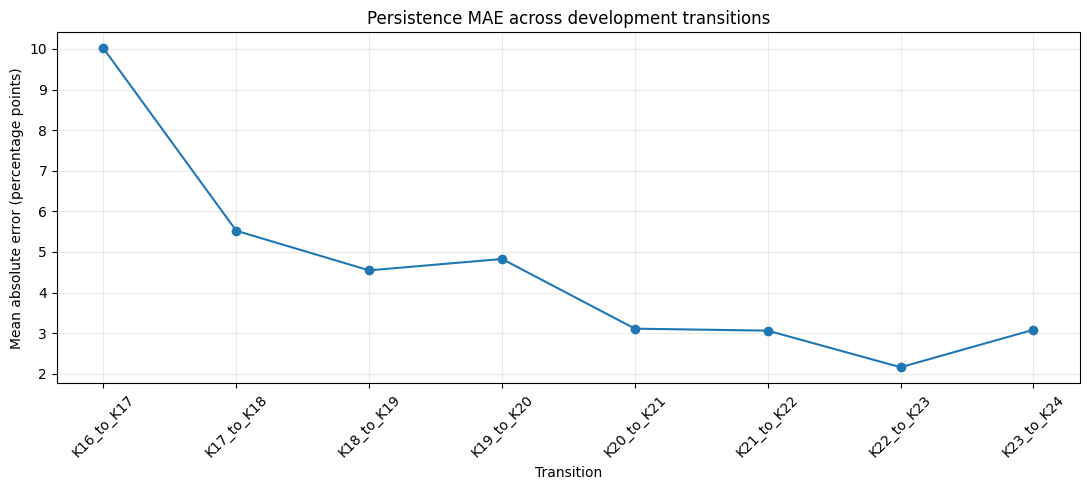

In [8]:
PERSISTENCE_BY_TRANSITION_FIGURE = (
    FIGURES_DIR / 'notebook_03_persistence_mae_by_transition.png'
)

figure, axis = plt.subplots(figsize=(11, 5))

axis.plot(
    development_transition_overview['transition_id'],
    development_transition_overview['persistence_mae'],
    marker='o',
)

axis.set_title('Persistence MAE across development transitions')
axis.set_xlabel('Transition')
axis.set_ylabel('Mean absolute error (percentage points)')
axis.tick_params(axis='x', rotation=45)
axis.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(
    PERSISTENCE_BY_TRANSITION_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

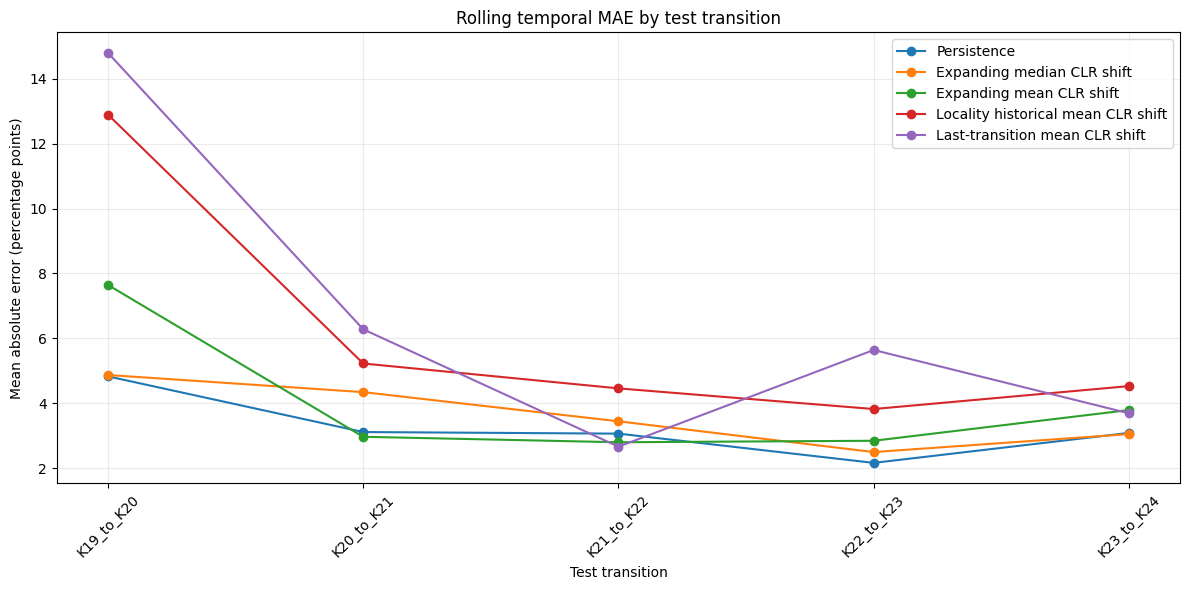

In [9]:
BASELINE_BY_FOLD_FIGURE = (
    FIGURES_DIR / 'notebook_03_baseline_mae_by_fold.png'
)

figure, axis = plt.subplots(figsize=(12, 6))

for model_name, model_frame in baseline_rolling_metrics.groupby(
    'model',
    sort=False,
):
    model_frame = model_frame.sort_values('transition_order')
    axis.plot(
        model_frame['transition_id'],
        model_frame['overall_mae'],
        marker='o',
        label=model_name,
    )

axis.set_title('Rolling temporal MAE by test transition')
axis.set_xlabel('Test transition')
axis.set_ylabel('Mean absolute error (percentage points)')
axis.tick_params(axis='x', rotation=45)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
figure.savefig(
    BASELINE_BY_FOLD_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

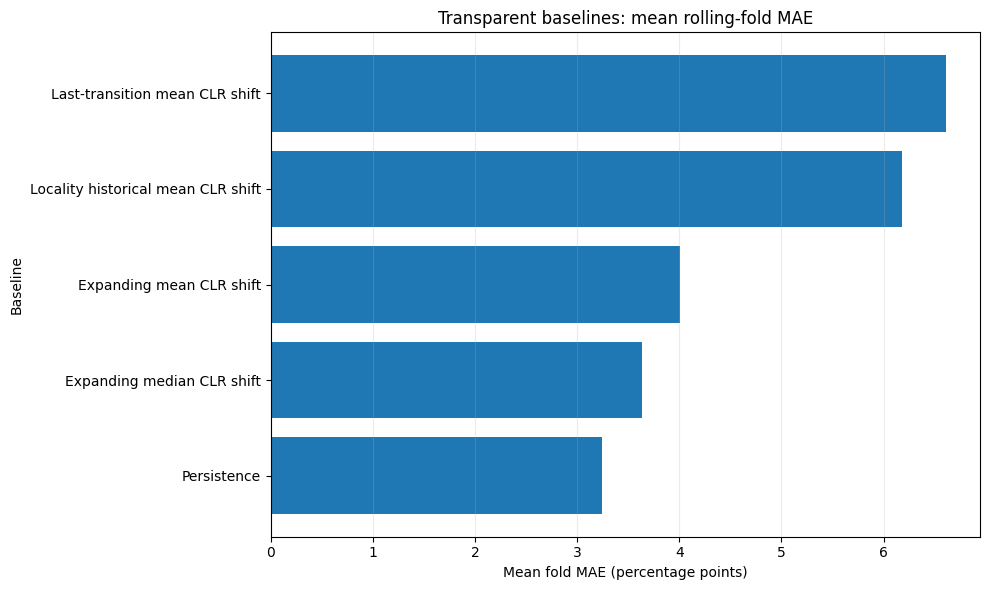

In [10]:
BASELINE_OVERALL_FIGURE = (
    FIGURES_DIR / 'notebook_03_baseline_mean_fold_mae.png'
)

plot_frame = baseline_overall_summary.sort_values(
    'mean_fold_mae',
    ascending=True,
)

figure, axis = plt.subplots(figsize=(10, 6))
axis.barh(
    plot_frame['model'],
    plot_frame['mean_fold_mae'],
)
axis.set_title('Transparent baselines: mean rolling-fold MAE')
axis.set_xlabel('Mean fold MAE (percentage points)')
axis.set_ylabel('Baseline')
axis.grid(axis='x', alpha=0.25)
figure.tight_layout()
figure.savefig(
    BASELINE_OVERALL_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

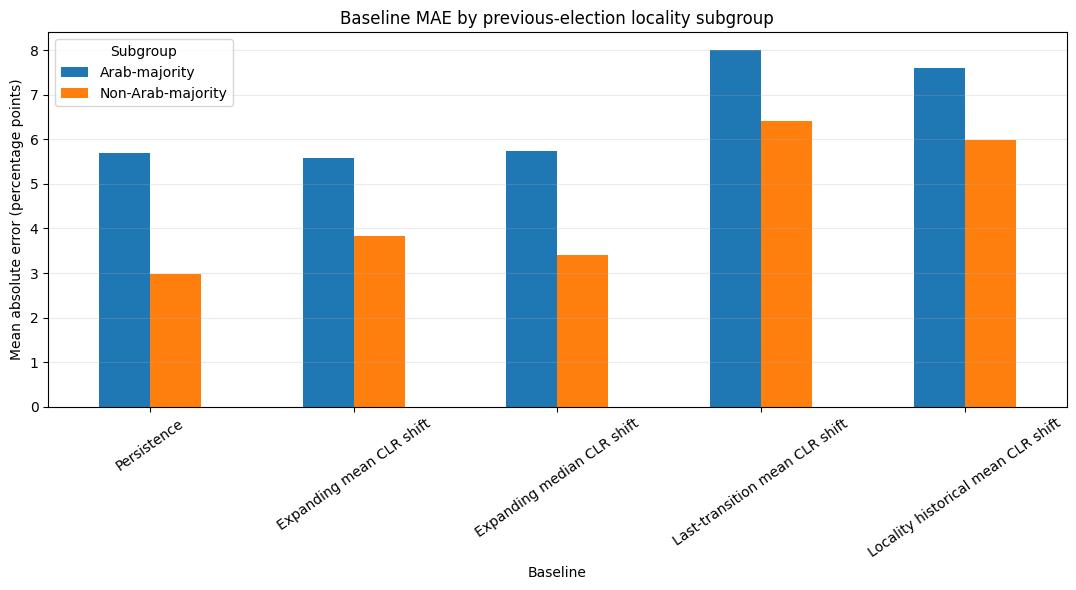

In [11]:
SUBGROUP_FIGURE = (
    FIGURES_DIR / 'notebook_03_baseline_subgroup_mae.png'
)

subgroup_pivot = baseline_subgroup_metrics.pivot(
    index='model',
    columns='subgroup',
    values='overall_mae',
).reindex(BASELINE_NAMES)

figure, axis = plt.subplots(figsize=(11, 6))
subgroup_pivot.plot(
    kind='bar',
    ax=axis,
)
axis.set_title('Baseline MAE by previous-election locality subgroup')
axis.set_xlabel('Baseline')
axis.set_ylabel('Mean absolute error (percentage points)')
axis.tick_params(axis='x', rotation=35)
axis.grid(axis='y', alpha=0.25)
axis.legend(title='Subgroup')
figure.tight_layout()
figure.savefig(
    SUBGROUP_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

/tmp/ipykernel_1939/2589963542.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


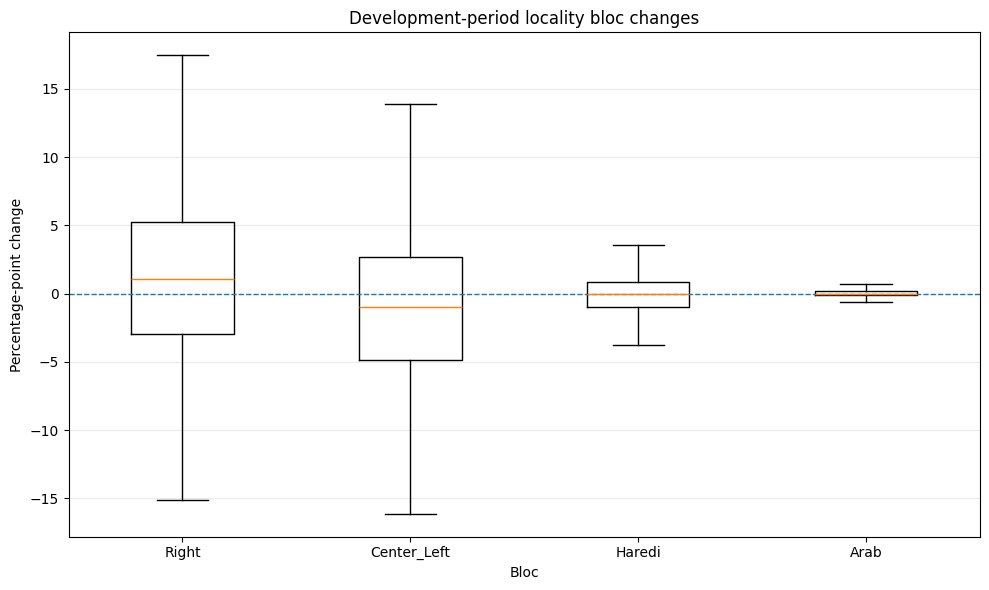

In [12]:
CHANGE_DISTRIBUTION_FIGURE = (
    FIGURES_DIR / 'notebook_03_development_change_distributions.png'
)

figure, axis = plt.subplots(figsize=(10, 6))

boxplot_data = [
    long_delta.loc[
        long_delta['bloc'].eq(bloc),
        'delta_pct',
    ]
    .dropna()
    .to_numpy()
    for bloc in MODELED_BLOCS
]

axis.boxplot(
    boxplot_data,
    labels=MODELED_BLOCS,
    showfliers=False,
)
axis.axhline(0, linestyle='--', linewidth=1)
axis.set_title('Development-period locality bloc changes')
axis.set_xlabel('Bloc')
axis.set_ylabel('Percentage-point change')
axis.grid(axis='y', alpha=0.25)
figure.tight_layout()
figure.savefig(
    CHANGE_DISTRIBUTION_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

## 8. Quality checks and leakage audit

In [13]:
quality_rows = []


def record_check(check, passed, value, requirement):
    quality_rows.append({
        'check': check,
        'passed': bool(passed),
        'value': value,
        'requirement': requirement,
    })


record_check(
    'all_notebook_02_quality_checks_passed',
    bool(nb02_quality['passed'].all()),
    int(nb02_quality['passed'].sum()),
    len(nb02_quality),
)

record_check(
    'all_nine_transitions_present',
    actual_transitions == EXPECTED_TRANSITIONS,
    str(actual_transitions),
    str(EXPECTED_TRANSITIONS),
)

record_check(
    'all_eight_development_transitions_present',
    sorted(development_panel['transition_id'].unique().tolist())
    == sorted(DEVELOPMENT_TRANSITIONS),
    sorted(development_panel['transition_id'].unique().tolist()),
    DEVELOPMENT_TRANSITIONS,
)

record_check(
    'only_k24_to_k25_is_locked',
    locked_transitions == [FINAL_TEST_TRANSITION],
    str(locked_transitions),
    str([FINAL_TEST_TRANSITION]),
)

prediction_transitions = sorted(
    baseline_rolling_predictions['transition_id']
    .unique()
    .tolist()
)

record_check(
    'final_test_absent_from_baseline_predictions',
    FINAL_TEST_TRANSITION not in prediction_transitions,
    prediction_transitions,
    f'{FINAL_TEST_TRANSITION} must be absent',
)

record_check(
    'five_rolling_temporal_test_folds_created',
    len(rolling_test_transitions) == 5,
    len(rolling_test_transitions),
    5,
)

record_check(
    'every_fold_has_at_least_three_training_transitions',
    bool(
        baseline_fold_definitions[
            'number_of_training_transitions'
        ].ge(MINIMUM_TRAIN_TRANSITIONS).all()
    ),
    int(
        baseline_fold_definitions[
            'number_of_training_transitions'
        ].min()
    ),
    f'>= {MINIMUM_TRAIN_TRANSITIONS}',
)

fold_temporal_order_is_valid = True

for row in baseline_fold_definitions.itertuples(index=False):
    test_order = DEVELOPMENT_TRANSITIONS.index(row.test_transition)
    training = row.training_transitions.split('|')

    if any(
        DEVELOPMENT_TRANSITIONS.index(transition) >= test_order
        for transition in training
    ):
        fold_temporal_order_is_valid = False
        break

record_check(
    'training_transitions_precede_test_transition',
    fold_temporal_order_is_valid,
    fold_temporal_order_is_valid,
    True,
)

predicted_share_columns = [
    f'predicted_{bloc}_pct'
    for bloc in MODELED_BLOCS
]

prediction_sum_error = float(
    baseline_rolling_predictions[
        predicted_share_columns
    ]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)

record_check(
    'all_predictions_sum_to_100',
    prediction_sum_error <= 1e-8,
    prediction_sum_error,
    '<= 1e-8',
)

minimum_prediction = float(
    baseline_rolling_predictions[
        predicted_share_columns
    ].min().min()
)

maximum_prediction = float(
    baseline_rolling_predictions[
        predicted_share_columns
    ].max().max()
)

record_check(
    'all_predictions_are_between_0_and_100',
    (
        minimum_prediction >= -1e-10
        and maximum_prediction <= 100 + 1e-10
    ),
    f'min={minimum_prediction}, max={maximum_prediction}',
    '0 <= prediction <= 100',
)

missing_prediction_values = int(
    baseline_rolling_predictions[
        predicted_share_columns
    ].isna().sum().sum()
)

record_check(
    'no_missing_prediction_values',
    missing_prediction_values == 0,
    missing_prediction_values,
    0,
)

expected_prediction_rows = (
    sum(
        int(
            development_panel['transition_id']
            .eq(transition)
            .sum()
        )
        for transition in rolling_test_transitions
    )
    * len(BASELINE_NAMES)
)

record_check(
    'prediction_row_count_is_complete',
    len(baseline_rolling_predictions)
    == expected_prediction_rows,
    len(baseline_rolling_predictions),
    expected_prediction_rows,
)

persistence_predictions = baseline_rolling_predictions.loc[
    baseline_rolling_predictions['model'].eq('Persistence')
]

persistence_check = persistence_predictions.merge(
    development_panel[
        [
            'transition_id',
            'locality_symbol',
            *previous_share_columns,
        ]
    ],
    on=['transition_id', 'locality_symbol'],
    how='left',
    validate='one_to_one',
)

persistence_max_difference = max(
    float(
        (
            persistence_check[f'predicted_{bloc}_pct']
            - persistence_check[f'previous_{bloc}_pct']
        )
        .abs()
        .max()
    )
    for bloc in MODELED_BLOCS
)

record_check(
    'persistence_predictions_equal_previous_shares',
    persistence_max_difference <= 1e-12,
    persistence_max_difference,
    '<= 1e-12',
)

notebook_03_quality_checks = pd.DataFrame(quality_rows)

display(notebook_03_quality_checks)

failed_checks = notebook_03_quality_checks.loc[
    ~notebook_03_quality_checks['passed']
]

if not failed_checks.empty:
    raise RuntimeError(
        'Notebook 03 quality checks failed:\n'
        + failed_checks.to_string(index=False)
    )

print('All Notebook 03 quality checks passed.')

,check,passed,value,requirement
0,all_notebook_02_quality_checks_passed,True,14,14
1,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
2,all_eight_development_transitions_present,True,"[K16_to_K17, K17_to_K18, K18_to_K19, K19_to_K2...","[K16_to_K17, K17_to_K18, K18_to_K19, K19_to_K2..."
3,only_k24_to_k25_is_locked,True,['K24_to_K25'],['K24_to_K25']
4,final_test_absent_from_baseline_predictions,True,"[K19_to_K20, K20_to_K21, K21_to_K22, K22_to_K2...",K24_to_K25 must be absent
5,five_rolling_temporal_test_folds_created,True,5,5
6,every_fold_has_at_least_three_training_transit...,True,3,>= 3
7,training_transitions_precede_test_transition,True,True,True
8,all_predictions_sum_to_100,True,0.0,<= 1e-8
9,all_predictions_are_between_0_and_100,True,"min=0.0, max=100.0",0 <= prediction <= 100


All Notebook 03 quality checks passed.


## 9. Save Notebook 03 outputs

In [14]:
OUTPUT_PATHS = {
    'development_transition_overview': (
        TABLES_DIR / 'notebook_03_development_transition_overview.csv'
    ),
    'bloc_change_summary': (
        TABLES_DIR / 'notebook_03_bloc_change_summary.csv'
    ),
    'fold_definitions': (
        TABLES_DIR / 'notebook_03_baseline_fold_definitions.csv'
    ),
    'rolling_metrics': (
        TABLES_DIR / 'notebook_03_baseline_rolling_metrics.csv'
    ),
    'fold_comparison': (
        TABLES_DIR / 'notebook_03_baseline_fold_comparison.csv'
    ),
    'rolling_predictions': (
        TABLES_DIR / 'notebook_03_baseline_rolling_predictions.csv'
    ),
    'overall_summary': (
        TABLES_DIR / 'notebook_03_baseline_overall_summary.csv'
    ),
    'subgroup_metrics': (
        TABLES_DIR / 'notebook_03_baseline_subgroup_metrics.csv'
    ),
    'size_band_metrics': (
        TABLES_DIR / 'notebook_03_baseline_size_band_metrics.csv'
    ),
    'quality_checks': (
        TABLES_DIR / 'notebook_03_quality_checks.csv'
    ),
    'persistence_figure': PERSISTENCE_BY_TRANSITION_FIGURE,
    'baseline_fold_figure': BASELINE_BY_FOLD_FIGURE,
    'baseline_overall_figure': BASELINE_OVERALL_FIGURE,
    'subgroup_figure': SUBGROUP_FIGURE,
    'change_distribution_figure': CHANGE_DISTRIBUTION_FIGURE,
    'summary': (
        SUMMARIES_DIR / 'notebook_03_summary.json'
    ),
}

development_transition_overview.to_csv(
    OUTPUT_PATHS['development_transition_overview'],
    index=False,
    encoding='utf-8-sig',
)

bloc_change_summary.to_csv(
    OUTPUT_PATHS['bloc_change_summary'],
    index=False,
    encoding='utf-8-sig',
)

baseline_fold_definitions.to_csv(
    OUTPUT_PATHS['fold_definitions'],
    index=False,
    encoding='utf-8-sig',
)

baseline_rolling_metrics.to_csv(
    OUTPUT_PATHS['rolling_metrics'],
    index=False,
    encoding='utf-8-sig',
)

baseline_fold_comparison.to_csv(
    OUTPUT_PATHS['fold_comparison'],
    index=False,
    encoding='utf-8-sig',
)

baseline_rolling_predictions.to_csv(
    OUTPUT_PATHS['rolling_predictions'],
    index=False,
    encoding='utf-8-sig',
)

baseline_overall_summary.to_csv(
    OUTPUT_PATHS['overall_summary'],
    index=False,
    encoding='utf-8-sig',
)

baseline_subgroup_metrics.to_csv(
    OUTPUT_PATHS['subgroup_metrics'],
    index=False,
    encoding='utf-8-sig',
)

baseline_size_band_metrics.to_csv(
    OUTPUT_PATHS['size_band_metrics'],
    index=False,
    encoding='utf-8-sig',
)

notebook_03_quality_checks.to_csv(
    OUTPUT_PATHS['quality_checks'],
    index=False,
    encoding='utf-8-sig',
)

summary = {
    'notebook': '03_eda_and_baselines',
    'version': 'final_after_full_history_notebook_02',
    'created_at_utc': time.strftime(
        '%Y-%m-%dT%H:%M:%SZ',
        time.gmtime(),
    ),
    'git_commit': GIT_COMMIT,
    'trusted_input': str(PANEL_PATH.relative_to(REPO_ROOT)),
    'notebook_02_version': nb02_summary.get('version'),
    'notebook_02_quality_checks_passed': True,
    'notebook_02_panel_rows': int(nb02_summary['panel_rows']),
    'notebook_02_unique_localities': int(nb02_summary['unique_localities']),
    'minimum_previous_vote_coverage_pct': minimum_previous_vote_coverage,
    'minimum_current_vote_coverage_pct': minimum_current_vote_coverage,
    'development_transitions': DEVELOPMENT_TRANSITIONS,
    'rolling_test_transitions': rolling_test_transitions,
    'final_test_transition': FINAL_TEST_TRANSITION,
    'final_test_locked': True,
    'final_test_used_for_eda': False,
    'final_test_used_for_baseline_comparison': False,
    'primary_metric': 'mean rolling-fold locality-level MAE',
    'arab_majority_threshold_pct': ARAB_MAJORITY_THRESHOLD_PCT,
    'largest_development_shift': str(
        largest_development_shift['transition_id']
    ),
    'largest_development_shift_persistence_mae': float(
        largest_development_shift['persistence_mae']
    ),
    'best_transparent_baseline': best_baseline_name,
    'best_mean_fold_mae': best_mean_fold_mae,
    'persistence_mean_fold_mae': persistence_mean_fold_mae,
    'best_relative_improvement_over_persistence_pct': (
        best_relative_improvement_pct
    ),
    'quality_checks_passed': bool(
        notebook_03_quality_checks['passed'].all()
    ),
    'outputs': {
        name: str(path.relative_to(REPO_ROOT))
        for name, path in OUTPUT_PATHS.items()
        if name != 'summary'
    },
}

OUTPUT_PATHS['summary'].write_text(
    json.dumps(
        summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

output_audit = pd.DataFrame([
    {
        'output': name,
        'relative_path': str(path.relative_to(REPO_ROOT)),
        'exists': path.exists(),
        'size_bytes': (
            path.stat().st_size
            if path.exists()
            else 0
        ),
    }
    for name, path in OUTPUT_PATHS.items()
])

display(output_audit)

bad_outputs = output_audit.loc[
    ~output_audit['exists']
    | output_audit['size_bytes'].le(0)
]

if not bad_outputs.empty:
    raise RuntimeError(
        'Missing or empty Notebook 03 outputs:\n'
        + bad_outputs.to_string(index=False)
    )

print('All Notebook 03 outputs were saved successfully.')

,output,relative_path,exists,size_bytes
0,development_transition_overview,reports/tables/notebook_03_development_transit...,True,1186
1,bloc_change_summary,reports/tables/notebook_03_bloc_change_summary...,True,9648
2,fold_definitions,reports/tables/notebook_03_baseline_fold_defin...,True,642
3,rolling_metrics,reports/tables/notebook_03_baseline_rolling_me...,True,5478
4,fold_comparison,reports/tables/notebook_03_baseline_fold_compa...,True,6394
5,rolling_predictions,reports/tables/notebook_03_baseline_rolling_pr...,True,14470241
6,overall_summary,reports/tables/notebook_03_baseline_overall_su...,True,1653
7,subgroup_metrics,reports/tables/notebook_03_baseline_subgroup_m...,True,2266
8,size_band_metrics,reports/tables/notebook_03_baseline_size_band_...,True,4319
9,quality_checks,reports/tables/notebook_03_quality_checks.csv,True,1335


All Notebook 03 outputs were saved successfully.


## 10. Download all Notebook 03 outputs

In [15]:
# Independent download cell: it does not depend on OUTPUT_PATHS.
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

repo_root = Path('/content/Election_Bloc_Prediction_Project_nb03')
zip_path = Path('/content/notebook_03_outputs.zip')

output_files = [
    repo_root / 'reports/tables/notebook_03_development_transition_overview.csv',
    repo_root / 'reports/tables/notebook_03_bloc_change_summary.csv',
    repo_root / 'reports/tables/notebook_03_baseline_fold_definitions.csv',
    repo_root / 'reports/tables/notebook_03_baseline_rolling_metrics.csv',
    repo_root / 'reports/tables/notebook_03_baseline_fold_comparison.csv',
    repo_root / 'reports/tables/notebook_03_baseline_rolling_predictions.csv',
    repo_root / 'reports/tables/notebook_03_baseline_overall_summary.csv',
    repo_root / 'reports/tables/notebook_03_baseline_subgroup_metrics.csv',
    repo_root / 'reports/tables/notebook_03_baseline_size_band_metrics.csv',
    repo_root / 'reports/tables/notebook_03_quality_checks.csv',
    repo_root / 'reports/figures/notebook_03_persistence_mae_by_transition.png',
    repo_root / 'reports/figures/notebook_03_baseline_mae_by_fold.png',
    repo_root / 'reports/figures/notebook_03_baseline_mean_fold_mae.png',
    repo_root / 'reports/figures/notebook_03_baseline_subgroup_mae.png',
    repo_root / 'reports/figures/notebook_03_development_change_distributions.png',
    repo_root / 'reports/summaries/notebook_03_summary.json',
]

existing_files = [
    path
    for path in output_files
    if path.exists() and path.stat().st_size > 0
]

missing_files = [
    str(path.relative_to(repo_root))
    for path in output_files
    if not path.exists() or path.stat().st_size <= 0
]

if missing_files:
    raise RuntimeError(
        'Run the Notebook 03 save cell first. Missing outputs:\n- '
        + '\n- '.join(missing_files)
    )

if zip_path.exists():
    zip_path.unlink()

with ZipFile(
    zip_path,
    mode='w',
    compression=ZIP_DEFLATED,
) as zip_file:
    for path in existing_files:
        zip_file.write(
            path,
            arcname=str(path.relative_to(repo_root)),
        )

print('ZIP created:', zip_path)
print('ZIP size:', zip_path.stat().st_size, 'bytes')
print('Files included:', len(existing_files))

files.download(str(zip_path))

ZIP created: /content/notebook_03_outputs.zip
ZIP size: 4633941 bytes
Files included: 16


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Completion criteria

A successful run ends with:

```text
Notebook 02 audits passed.
Transition-panel validation passed.
All Notebook 03 quality checks passed.
All Notebook 03 outputs were saved successfully.
ZIP created: /content/notebook_03_outputs.zip
```

The notebook must report exactly five rolling test folds and must never include `K24_to_K25` in prediction or performance tables.